In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

# ── Plot style ──────────────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# ── Date range (matches group convention) ───────────────────
START_DATE = "2018-01-01"
END_DATE   = "2025-01-01"

print(f"Date Range: {START_DATE} → {END_DATE}")


Date Range: 2018-01-01 → 2025-01-01


In [21]:
vix_raw = yf.download("^VIX", start=START_DATE, end=END_DATE, auto_adjust=True)

# Keep only closing price
vix = vix_raw[["Close"]].copy()
vix.columns = ["VIX"]
vix.index.name = "Date"

# Save raw data
vix.to_csv("data/vix_raw.csv")

# Inspect
print(f"Shape: {vix.shape}")
print(f"Date range: {vix.index.min()} → {vix.index.max()}")
print(f"Nulls: {vix.isnull().sum().values[0]}")
print()
print(vix.describe().round(2))


[*********************100%***********************]  1 of 1 completed

Shape: (1761, 1)
Date range: 2018-01-02 00:00:00 → 2024-12-31 00:00:00
Nulls: 0

           VIX
count  1761.00
mean     19.87
std       7.71
min       9.15
25%      14.48
50%      18.04
75%      22.89
max      82.69


In [22]:
# Log returns — removes temporal component for static distribution analysis
vix["Log_Return"] = np.log(vix["VIX"] / vix["VIX"].shift(1))
vix = vix.dropna()

print(f"Log returns shape: {vix.shape}")
print(f"Nulls after drop: {vix['Log_Return'].isnull().sum()}")
print()
print(vix["Log_Return"].describe().round(4))

Log returns shape: (1760, 2)
Nulls after drop: 0

count    1760.0000
mean        0.0003
std         0.0813
min        -0.3307
25%        -0.0449
50%        -0.0080
75%         0.0345
max         0.7682
Name: Log_Return, dtype: float64


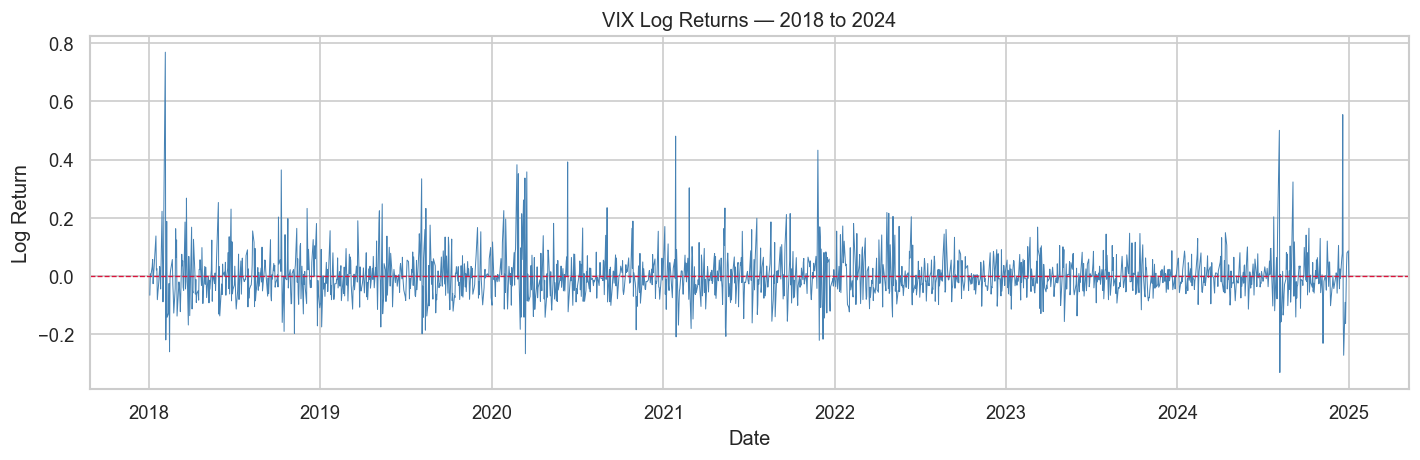

In [23]:
# Log return time series
plt.figure(figsize=(12, 4))
plt.plot(vix.index, vix["Log_Return"], color="steelblue", linewidth=0.6)
plt.axhline(0, color="crimson", linewidth=0.8, linestyle="--")
plt.title("VIX Log Returns — 2018 to 2024")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.tight_layout()
plt.show()

Cool Spikes you can lowkey kind of tell what happened duirng each time lol(Covid, russia ukraine idk what happened 2022 and 2018 though)


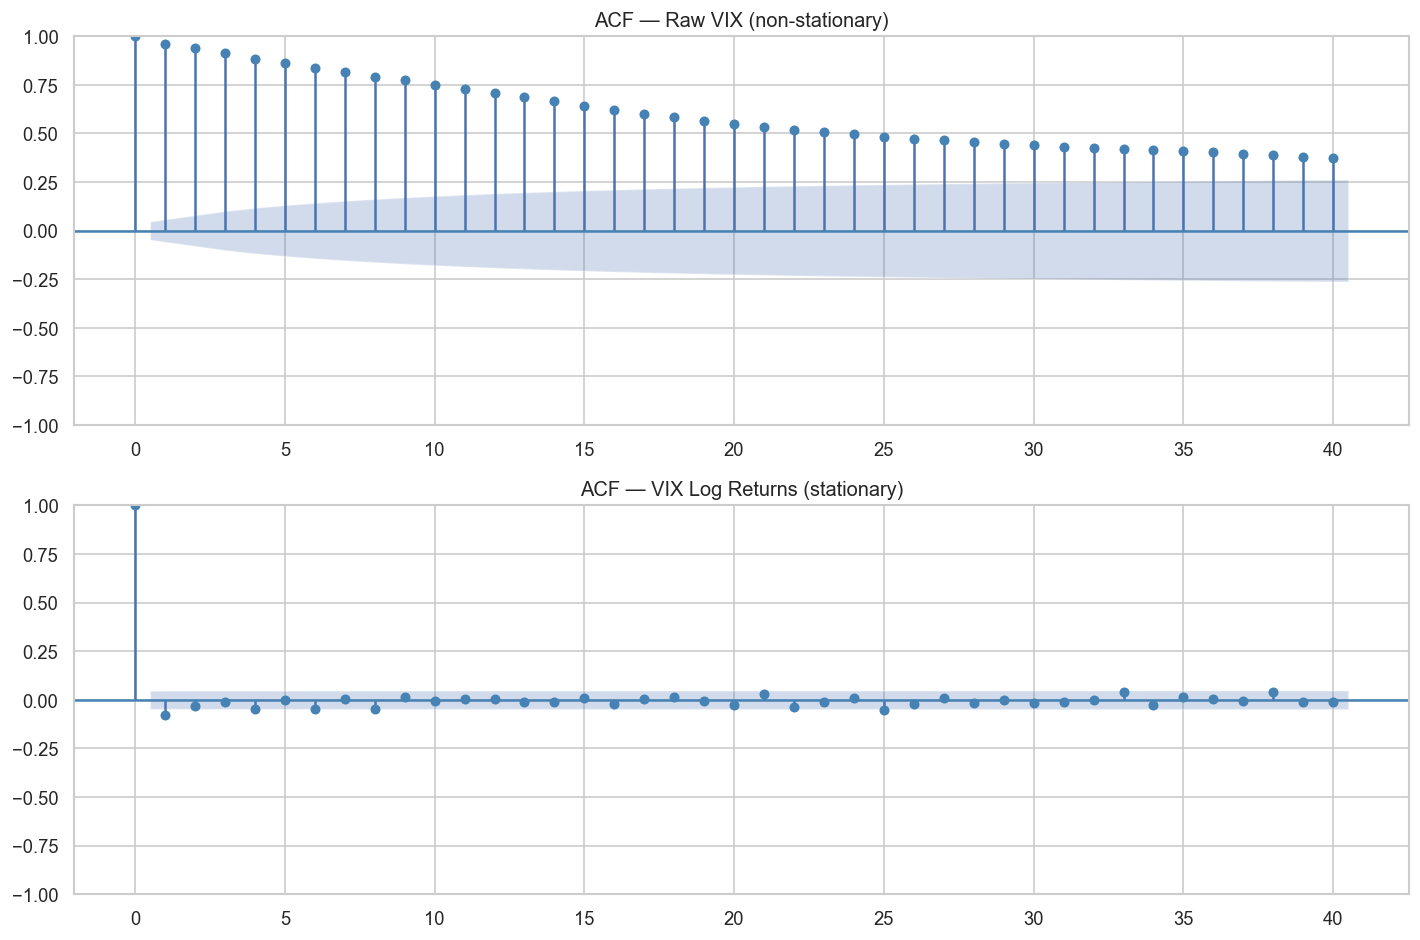

In [24]:
# ACF plots — raw VIX vs log returns (justifies transformation)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

sm.graphics.tsa.plot_acf(vix["VIX"].dropna(), lags=40, ax=axes[0],
                          color="steelblue", title="ACF — Raw VIX (non-stationary)")

sm.graphics.tsa.plot_acf(vix["Log_Return"].dropna(), lags=40, ax=axes[1],
                          color="steelblue", title="ACF — VIX Log Returns (stationary)")

plt.tight_layout()
plt.show()

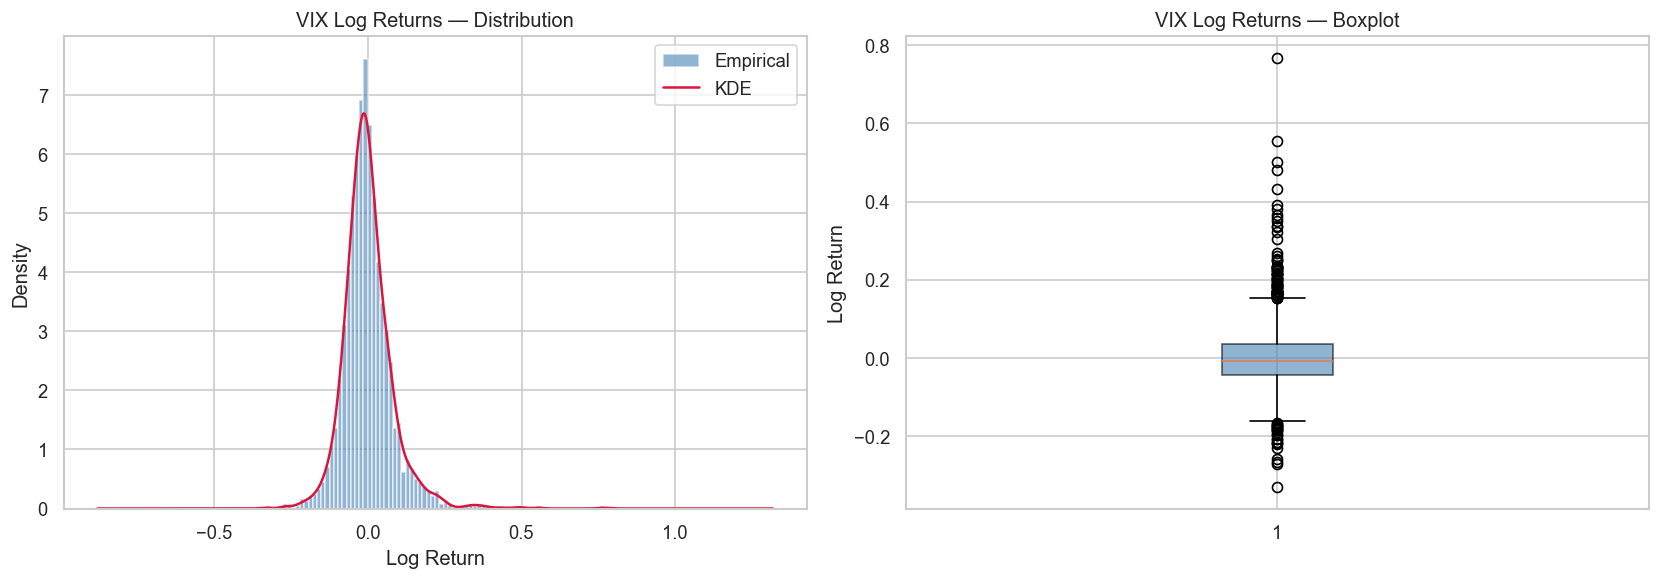

Skewness : 1.5648
Kurtosis : 9.2275  (excess, normal = 0)


In [25]:
# Distribution of log returns — histogram + KDE
lr = vix["Log_Return"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
axes[0].hist(lr, bins=80, density=True, color="steelblue", alpha=0.6, label="Empirical")
lr.plot.kde(ax=axes[0], color="crimson", linewidth=1.5, label="KDE")
axes[0].set_title("VIX Log Returns — Distribution")
axes[0].set_xlabel("Log Return")
axes[0].legend()

# Boxplot
axes[1].boxplot(lr, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_title("VIX Log Returns — Boxplot")
axes[1].set_ylabel("Log Return")

plt.tight_layout()
plt.show()

# Summary stats
print(f"Skewness : {lr.skew():.4f}")
print(f"Kurtosis : {lr.kurtosis():.4f}  (excess, normal = 0)")

asking claude what these results meant. Skewness = 1.56 — significantly right-skewed, fear spikes up faster than it decays
Kurtosis = 9.23 — massively fat-tailed (normal = 0, anything above ~3 is considered heavy-tailed)
Boxplot — the IQR is tiny but there are extreme outliers on both ends, especially upside

This is textbook evidence that Gaussian is a poor fit and Student-t is the right call. The kurtosis of 9.23 basically makes that argument for you without even running a test.


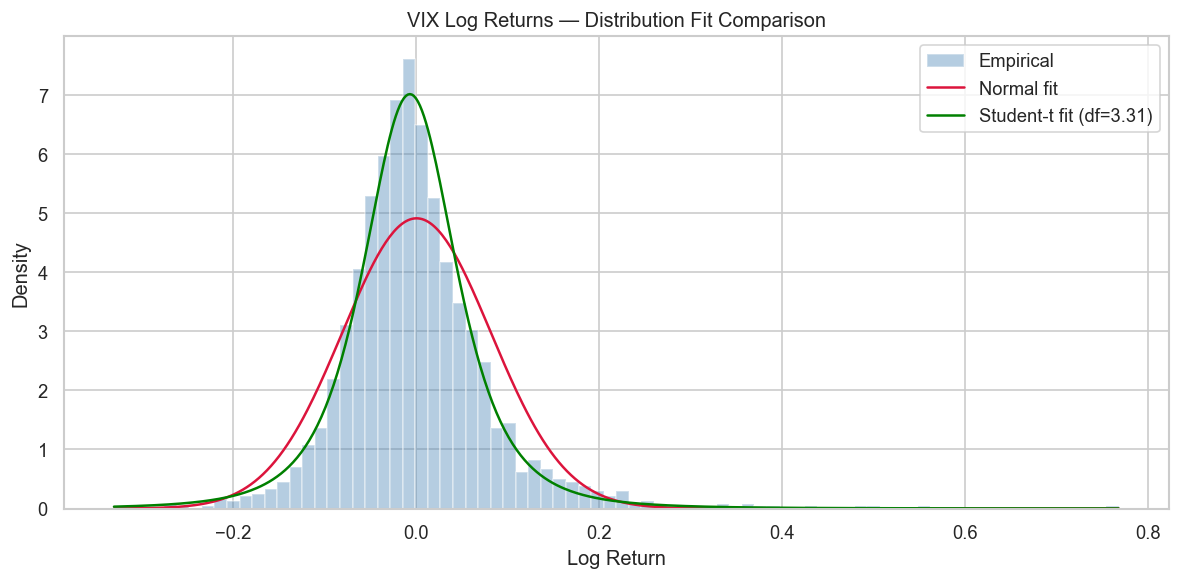

In [26]:
# Overlay fitted distributions on histogram
x = np.linspace(lr.min(), lr.max(), 500)

mu, std = stats.norm.fit(lr)
df_t, loc_t, scale_t = stats.t.fit(lr)

plt.figure(figsize=(10, 5))
plt.hist(lr, bins=80, density=True, color="steelblue", alpha=0.4, label="Empirical")
plt.plot(x, stats.norm.pdf(x, mu, std), color="crimson", linewidth=1.5, label="Normal fit")
plt.plot(x, stats.t.pdf(x, df_t, loc_t, scale_t), color="green", linewidth=1.5, label=f"Student-t fit (df={df_t:.2f})")
plt.title("VIX Log Returns — Distribution Fit Comparison")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# KS test — Goodness of fit for Normal vs Student-t
mu, std       = stats.norm.fit(lr)
df_t, loc_t, scale_t = stats.t.fit(lr)

ks_norm = stats.kstest(lr, "norm", args=(mu, std))
ks_t    = stats.kstest(lr, "t",    args=(df_t, loc_t, scale_t))

print("Kolmogorov-Smirnov Test")
print(f"  Normal:    statistic={ks_norm.statistic:.4f},  p-value={ks_norm.pvalue:.6f}")
print(f"  Student-t: statistic={ks_t.statistic:.4f},  p-value={ks_t.pvalue:.6f}")
print()
print("Lower KS statistic = better fit")
print("p-value < 0.05 = reject that distribution fits the data")

Kolmogorov-Smirnov Test
  Normal:    statistic=0.0893,  p-value=0.000000
  Student-t: statistic=0.0268,  p-value=0.157094

Lower KS statistic = better fit
p-value < 0.05 = reject that distribution fits the data


In [28]:
# Frequentist parameter estimation — MLE
mu_mle, std_mle       = stats.norm.fit(lr)
df_mle, loc_mle, scale_mle = stats.t.fit(lr)

# Confidence intervals for Normal MLE (analytical)
n = len(lr)
se_mu  = std_mle / np.sqrt(n)
ci_low = mu_mle - 1.96 * se_mu
ci_up  = mu_mle + 1.96 * se_mu

print("Maximum Likelihood Estimation (Frequentist)")
print()
print("Normal distribution:")
print(f"  μ (mean) = {mu_mle:.6f}")
print(f"  σ (std)  = {std_mle:.6f}")
print(f"  95% CI on μ: [{ci_low:.6f}, {ci_up:.6f}]")
print()
print("Student-t distribution:")
print(f"  df (degrees of freedom) = {df_mle:.4f}")
print(f"  μ (location) = {loc_mle:.6f}")
print(f"  σ (scale)    = {scale_mle:.6f}")
print()
print("Interpretation: MLE finds parameters that maximise")
print("the likelihood of observing this data under each distribution.")

Maximum Likelihood Estimation (Frequentist)

Normal distribution:
  μ (mean) = 0.000326
  σ (std)  = 0.081253
  95% CI on μ: [-0.003470, 0.004122]

Student-t distribution:
  df (degrees of freedom) = 3.3130
  μ (location) = -0.007027
  σ (scale)    = 0.052818

Interpretation: MLE finds parameters that maximise
the likelihood of observing this data under each distribution.


claude. Normal μ ≈ 0 — mean log return is essentially zero, expected
95% CI on μ straddles zero — confirms mean return is not significantly different from zero
Student-t df = 3.31 — very low degrees of freedom, confirms extremely fat tails (df < 5 is considered heavy-tailed in finance)
Student-t scale (0.053) < Normal std (0.081) — because the t-distribution handles the tail mass separately via df, the central scale parameter is tighter

In [29]:
# Bayesian parameter estimation conjugate prior (Normal distribution)
# Using Normal-inverse approach: update prior beliefs with observed data

n      = len(lr)
x_bar  = lr.mean()
s2     = lr.var()

# Prior (weakly informative — low confidence prior centred at 0)
mu_0    = 0.0      # prior belief: mean return is 0
kappa_0 = 1        # prior strength (equivalent sample size)
alpha_0 = 2.0      # prior shape for variance
beta_0  = 0.01     # prior scale for variance

# Posterior updates (Normal-Inverse-Gamma conjugate)
kappa_n = kappa_0 + n
mu_n    = (kappa_0 * mu_0 + n * x_bar) / kappa_n
alpha_n = alpha_0 + n / 2
beta_n  = beta_0 + 0.5 * n * s2 + (kappa_0 * n * (x_bar - mu_0)**2) / (2 * kappa_n)

# Posterior mean and variance estimates
post_mean     = mu_n
post_variance = beta_n / (alpha_n - 1)
post_std      = np.sqrt(post_variance)

print("Bayesian Parameter Estimation (Conjugate Prior)")
print()
print("Prior beliefs:")
print(f"  μ₀ = {mu_0},  κ₀ = {kappa_0},  α₀ = {alpha_0},  β₀ = {beta_0}")
print()
print("Posterior estimates:")
print(f"  μ  (posterior mean)     = {post_mean:.6f}")
print(f"  σ² (posterior variance) = {post_variance:.6f}")
print(f"  σ  (posterior std)      = {post_std:.6f}")
print()
print("Interpretation: posterior is dominated by data (n=1760)")
print("so prior has minimal influence on the result.")

Bayesian Parameter Estimation (Conjugate Prior)

Prior beliefs:
  μ₀ = 0.0,  κ₀ = 1,  α₀ = 2.0,  β₀ = 0.01

Posterior estimates:
  μ  (posterior mean)     = 0.000326
  σ² (posterior variance) = 0.006610
  σ  (posterior std)      = 0.081300

Interpretation: posterior is dominated by data (n=1760)
so prior has minimal influence on the result.


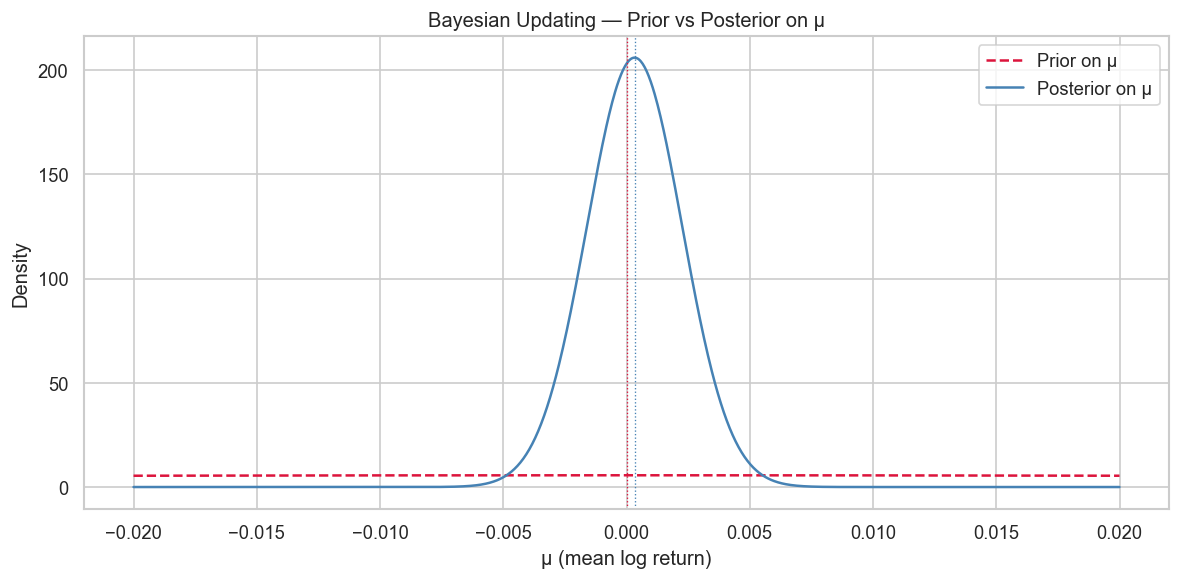

In [30]:
# Visualise Bayesian updating — prior vs posterior on μ
mu_grid = np.linspace(-0.02, 0.02, 1000)

# Prior distribution on μ (before seeing data)
prior_std  = np.sqrt(beta_0 / (alpha_0 * kappa_0))
prior_pdf  = stats.norm.pdf(mu_grid, mu_0, prior_std)

# Posterior distribution on μ (after seeing data)
post_std_mu = np.sqrt(beta_n / (alpha_n * kappa_n))
post_pdf    = stats.norm.pdf(mu_grid, mu_n, post_std_mu)

plt.figure(figsize=(10, 5))
plt.plot(mu_grid, prior_pdf, color="crimson", linewidth=1.5, linestyle="--", label="Prior on μ")
plt.plot(mu_grid, post_pdf, color="steelblue", linewidth=1.5, label="Posterior on μ")
plt.axvline(mu_n, color="steelblue", linewidth=0.8, linestyle=":")
plt.axvline(mu_0, color="crimson", linewidth=0.8, linestyle=":")
plt.title("Bayesian Updating — Prior vs Posterior on μ")
plt.xlabel("μ (mean log return)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# Summary — Frequentist vs Bayesian comparison
print("=" * 55)
print("Parameter Estimation Summary — VIX Log Returns")
print("=" * 55)
print(f"{'Parameter':<25} {'Frequentist':>14} {'Bayesian':>14}")
print("-" * 55)
print(f"{'μ (mean)':<25} {mu_mle:>14.6f} {post_mean:>14.6f}")
print(f"{'σ (std)':<25} {std_mle:>14.6f} {post_std:>14.6f}")
print(f"{'Distribution fit':<25} {'Student-t':>14} {'Normal':>14}")
print(f"{'df (Student-t)':<25} {df_mle:>14.4f} {'N/A':>14}")
print(f"{'KS stat (Normal)':<25} {ks_norm.statistic:>14.4f} {'':>14}")
print(f"{'KS stat (Student-t)':<25} {ks_t.statistic:>14.4f} {'':>14}")
print(f"{'KS p-val (Student-t)':<25} {ks_t.pvalue:>14.4f} {'':>14}")
print("=" * 55)
print()
print("Conclusion:")
print("  - VIX log returns are right-skewed (skew=1.56)")
print("  - Fat-tailed (excess kurtosis=9.23)")
print("  - Student-t (df=3.31) significantly outperforms Normal")
print("  - Frequentist and Bayesian μ estimates converge (n=1760)")
print("  - Weak prior is overwhelmed by data in Bayesian approach")

Parameter Estimation Summary — VIX Log Returns
Parameter                    Frequentist       Bayesian
-------------------------------------------------------
μ (mean)                        0.000326       0.000326
σ (std)                         0.081253       0.081300
Distribution fit               Student-t         Normal
df (Student-t)                    3.3130            N/A
KS stat (Normal)                  0.0893               
KS stat (Student-t)               0.0268               
KS p-val (Student-t)              0.1571               

Conclusion:
  - VIX log returns are right-skewed (skew=1.56)
  - Fat-tailed (excess kurtosis=9.23)
  - Student-t (df=3.31) significantly outperforms Normal
  - Frequentist and Bayesian μ estimates converge (n=1760)
  - Weak prior is overwhelmed by data in Bayesian approach
